In [1]:
# !pip install pydeseq2

In [1]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import pandas as pd

In [43]:
counts = pd.read_csv('classic_mono_umi_counts.csv')
# counts.rename(columns={'Unnamed: 0':'Gene'}, inplace=True)
counts = counts.set_index('Gene')
# counts = counts[counts.sum(axis = 1) > 0]
counts

,Classic Monocytes_PBMCs 1,Classic Monocytes_PBMCs 2,Classic Monocytes_PBMCs 3,Classic Monocytes_PBMCs + TNFa 1,Classic Monocytes_PBMCs + TNFa 2,Classic Monocytes_PBMCs + TNFa 3,Classic Monocytes_PBMCs RA 1,Classic Monocytes_PBMCs RA 2,Classic Monocytes_PBMCs RA 3,Classic Monocytes_PBMCs RA + TNFa 1,Classic Monocytes_PBMCs RA + TNFa 2,Classic Monocytes_PBMCs RA + TNFa 3
Gene,,,,,,,,,,,,
MT-CO1,52332,187919,92980,29052,152077,94058,21550,57160,22254,16216,64465,20520
FTH1,43791,174643,100485,25095,145746,107086,23780,95007,30541,20836,108269,27854
THBS1,32842,113616,68423,18124,83981,65251,13819,43318,18198,11039,44763,16689
SERPINB2,28016,87652,49962,22769,78710,59491,11102,56101,18998,15266,68087,23329
MT-ND4,25084,85237,42031,13999,70180,43258,12906,31915,11617,9710,36505,10786
...,...,...,...,...,...,...,...,...,...,...,...,...
SPRR4,0,0,0,0,0,0,0,0,0,0,0,0
TRBV22-1,0,0,0,0,0,0,0,0,0,0,0,0
ZSWIM8-AS1,0,0,0,0,0,0,0,0,0,0,0,0


In [44]:
counts = counts.T
counts

Gene,MT-CO1,FTH1,THBS1,SERPINB2,MT-ND4,MT-ND1,IL1B,MT-ND2,MT-CO2,MT-ND3,...,RNF151,SCGB1D1,SMIM38,SPATA31D4,SPRR3,SPRR4,TRBV22-1,ZSWIM8-AS1,CD120A,CD120B
Classic Monocytes_PBMCs 1,52332,43791,32842,28016,25084,19877,11109,19134,23266,19549,...,0,0,0,0,0,0,0,0,1958,38283
Classic Monocytes_PBMCs 2,187919,174643,113616,87652,85237,80108,48079,74392,72828,71197,...,0,0,0,0,0,0,0,0,8592,140312
Classic Monocytes_PBMCs 3,92980,100485,68423,49962,42031,43470,19667,40145,37866,36997,...,0,0,0,0,0,0,0,0,4565,71371
Classic Monocytes_PBMCs + TNFa 1,29052,25095,18124,22769,13999,11459,13600,10821,12802,11018,...,0,0,0,0,0,0,0,0,546,9461
Classic Monocytes_PBMCs + TNFa 2,152077,145746,83981,78710,70180,65713,64676,60619,59408,58853,...,0,0,0,0,0,0,0,0,3167,54790
Classic Monocytes_PBMCs + TNFa 3,94058,107086,65251,59491,43258,43846,39967,39972,38240,37074,...,0,0,0,0,0,0,0,0,1923,22786
Classic Monocytes_PBMCs RA 1,21550,23780,13819,11102,12906,16016,2718,12039,10903,10355,...,0,0,0,0,0,0,0,0,2054,13647
Classic Monocytes_PBMCs RA 2,57160,95007,43318,56101,31915,29946,24976,25609,30876,24682,...,0,0,0,0,0,0,0,0,4420,45740
Classic Monocytes_PBMCs RA 3,22254,30541,18198,18998,11617,11860,8604,12340,11119,9506,...,0,0,0,0,0,0,0,0,1261,13113
Classic Monocytes_PBMCs RA + TNFa 1,16216,20836,11039,15266,9710,11847,3964,8539,8026,7447,...,0,0,0,0,0,0,0,0,617,5210


In [65]:
PBMCs = counts.iloc[0:3]
PBMCs_TNFa = counts.iloc[3:6]
RA_PBMCs = counts.iloc[6:9]
RA_PBMCs_TNFa = counts.iloc[9:12]
PBMCs

Gene,MT-CO1,FTH1,THBS1,SERPINB2,MT-ND4,MT-ND1,IL1B,MT-ND2,MT-CO2,MT-ND3,...,RNF151,SCGB1D1,SMIM38,SPATA31D4,SPRR3,SPRR4,TRBV22-1,ZSWIM8-AS1,CD120A,CD120B
Classic Monocytes_PBMCs 1,52332,43791,32842,28016,25084,19877,11109,19134,23266,19549,...,0,0,0,0,0,0,0,0,1958,38283
Classic Monocytes_PBMCs 2,187919,174643,113616,87652,85237,80108,48079,74392,72828,71197,...,0,0,0,0,0,0,0,0,8592,140312
Classic Monocytes_PBMCs 3,92980,100485,68423,49962,42031,43470,19667,40145,37866,36997,...,0,0,0,0,0,0,0,0,4565,71371


In [86]:
counts_Ex_C = pd.concat([PBMCs_TNFa,PBMCs])
counts_Ex_C

Gene,MT-CO1,FTH1,THBS1,SERPINB2,MT-ND4,MT-ND1,IL1B,MT-ND2,MT-CO2,MT-ND3,...,RNF151,SCGB1D1,SMIM38,SPATA31D4,SPRR3,SPRR4,TRBV22-1,ZSWIM8-AS1,CD120A,CD120B
Classic Monocytes_PBMCs + TNFa 1,29052,25095,18124,22769,13999,11459,13600,10821,12802,11018,...,0,0,0,0,0,0,0,0,546,9461
Classic Monocytes_PBMCs + TNFa 2,152077,145746,83981,78710,70180,65713,64676,60619,59408,58853,...,0,0,0,0,0,0,0,0,3167,54790
Classic Monocytes_PBMCs + TNFa 3,94058,107086,65251,59491,43258,43846,39967,39972,38240,37074,...,0,0,0,0,0,0,0,0,1923,22786
Classic Monocytes_PBMCs 1,52332,43791,32842,28016,25084,19877,11109,19134,23266,19549,...,0,0,0,0,0,0,0,0,1958,38283
Classic Monocytes_PBMCs 2,187919,174643,113616,87652,85237,80108,48079,74392,72828,71197,...,0,0,0,0,0,0,0,0,8592,140312
Classic Monocytes_PBMCs 3,92980,100485,68423,49962,42031,43470,19667,40145,37866,36997,...,0,0,0,0,0,0,0,0,4565,71371


In [87]:
metadata_Ex_C = pd.DataFrame(zip(counts_Ex_C.index, ['E','E','E',
                                                       # 'E','E','E',
                                                       'C','C','C'
                                                       # ,'C','C','C'
                                                      ],['1','2','3',
                                                       # 'E','E','E',
                                                       '1','2','3'
                                                       # ,'C','C','C'
                                                      ]),
                        columns = ['Sample', 'Condition','Patient'])
metadata_Ex_C = metadata_Ex_C.set_index('Sample')

metadata_Ex_C

,Condition,Patient
Sample,,
Classic Monocytes_PBMCs + TNFa 1,E,1
Classic Monocytes_PBMCs + TNFa 2,E,2
Classic Monocytes_PBMCs + TNFa 3,E,3
Classic Monocytes_PBMCs 1,C,1
Classic Monocytes_PBMCs 2,C,2
Classic Monocytes_PBMCs 3,C,3


In [88]:
dds = DeseqDataSet(counts=counts_Ex_C,
              metadata=metadata_Ex_C,
              design_factors=['Patient', 'Condition'])


#design_factors=["batch", "condition"] = ~ batch + condtion

dds.deseq2()

stat_res = DeseqStats(dds, contrast = ('Condition','E','C'))
stat_res.summary()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.76 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/lib/python3.11/site-packages/pydeseq2/dds.py:715: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.27 seconds.

/opt/anaconda3/lib/python3.11/site-packages/pydeseq2/dds.py:490: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.72 seconds.

Fitting LFCs...
... done in 1.28 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Condition E vs C
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gene                                                                         
MT-CO1      84474.700213       -0.012263  0.150097 -0.081703  9.348826e-01   
FTH1        81545.476864        0.042856  0.154881  0.276704  7.820071e-01   
THBS1       53811.144220       -0.087374  0.022736 -3.842909  1.215846e-04   
SERPINB2    48636.059438        0.299345  0.198536  1.507761  1.316158e-01   
MT-ND4      39251.454110        0.006895  0.153773  0.044837  9.642372e-01   
...                  ...             ...       ...       ...           ...   
SPRR4           0.000000             NaN       NaN       NaN           NaN   
TRBV22-1        0.000000             NaN       NaN       NaN           NaN   
ZSWIM8-AS1      0.000000             NaN       NaN       NaN           NaN   
CD120A       2708.379656       -1.143841  0.166929 -6.852273  7.268586e-12   
CD120B   

... done in 0.87 seconds.



In [89]:
res = stat_res.results_df
res['log2FoldChange'] = res['log2FoldChange'].astype('float')
res['padj'] = res['padj'].astype('float')
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
MT-CO1,84474.700213,-0.012263,0.150097,-0.081703,9.348826e-01,9.996980e-01
FTH1,81545.476864,0.042856,0.154881,0.276704,7.820071e-01,9.996980e-01
THBS1,53811.144220,-0.087374,0.022736,-3.842909,1.215846e-04,2.307827e-02
SERPINB2,48636.059438,0.299345,0.198536,1.507761,1.316158e-01,9.996980e-01
MT-ND4,39251.454110,0.006895,0.153773,0.044837,9.642372e-01,9.996980e-01
...,...,...,...,...,...,...
SPRR4,0.000000,NaN,NaN,NaN,NaN,NaN
TRBV22-1,0.000000,NaN,NaN,NaN,NaN,NaN
ZSWIM8-AS1,0.000000,NaN,NaN,NaN,NaN,NaN


In [90]:
res = res[res['baseMean'] > 91]
res = res.dropna()
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
MT-CO1,84474.700213,-0.012263,0.150097,-0.081703,9.348826e-01,9.996980e-01
FTH1,81545.476864,0.042856,0.154881,0.276704,7.820071e-01,9.996980e-01
THBS1,53811.144220,-0.087374,0.022736,-3.842909,1.215846e-04,2.307827e-02
SERPINB2,48636.059438,0.299345,0.198536,1.507761,1.316158e-01,9.996980e-01
MT-ND4,39251.454110,0.006895,0.153773,0.044837,9.642372e-01,9.996980e-01
...,...,...,...,...,...,...
NDUFA12,204.221803,0.032604,0.218040,0.149533,8.811331e-01,9.996980e-01
GJA3,235.572631,0.029446,0.380809,0.077324,9.383660e-01,9.996980e-01
GRIP1,603.678410,-1.497323,1.465823,-1.021489,3.070226e-01,9.996980e-01


In [91]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]
sigs.to_csv('DeSeq2_sigs.csv')
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
IL1B,28107.913087,0.947863,0.208871,4.538036,5.678047e-06,2.874038e-03
MARCKS,5022.380145,0.572889,0.152505,3.756523,1.722907e-04,2.616234e-02
C5AR1,6440.717471,-0.596119,0.165791,-3.595603,3.236415e-04,3.780381e-02
CCL4,2191.363868,1.065033,0.260489,4.088590,4.340029e-05,1.280170e-02
CCL3,2418.030039,1.095095,0.262954,4.164589,3.119144e-05,1.184105e-02
ANXA1,3788.154398,-0.574678,0.158658,-3.622115,2.922043e-04,3.697602e-02
SGPP2,2181.683570,0.650528,0.171210,3.799599,1.449302e-04,2.445295e-02
G0S2,1136.255214,0.632319,0.173474,3.645031,2.673598e-04,3.690780e-02
SLC39A8,1726.430903,0.600416,0.157095,3.821994,1.323768e-04,2.364873e-02


In [92]:
res.to_csv('DeSeq2_N_res.csv')

In [81]:
# res_N = res

In [85]:
# res_R = res

In [97]:
metadata = pd.DataFrame(zip(counts.index, ['PBMCs','PBMCs','PBMCs','PBMCs + TNF','PBMCs + TNF','PBMCs + TNF',
                                           # '1','1','1','1','1','1',
                                           # '2','2','2','2','2','2',
                                           'PBMCs RA','PBMCs RA','PBMCs RA','PBMCs RA + TNF','PBMCs RA + TNF','PBMCs RA + TNF']),
                        columns = ['Sample', 'Condition'])
metadata = metadata.set_index('Sample')

dds = DeseqDataSet(counts=counts,
              metadata=metadata,
            design_factors="Condition")

dds.deseq2()

df = pd.DataFrame(dds.layers["normed_counts"], columns=counts.columns, index=counts.index)
df = df.T
df.to_csv('DeSeq2_normed_counts.csv')
df

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.04 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

Fitting MAP dispersions...
... done in 1.45 seconds.

Fitting LFCs...
... done in 1.50 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



,Classic Monocytes_PBMCs 1,Classic Monocytes_PBMCs 2,Classic Monocytes_PBMCs 3,Classic Monocytes_PBMCs + TNFa 1,Classic Monocytes_PBMCs + TNFa 2,Classic Monocytes_PBMCs + TNFa 3,Classic Monocytes_PBMCs RA 1,Classic Monocytes_PBMCs RA 2,Classic Monocytes_PBMCs RA 3,Classic Monocytes_PBMCs RA + TNFa 1,Classic Monocytes_PBMCs RA + TNFa 2,Classic Monocytes_PBMCs RA + TNFa 3
Gene,,,,,,,,,,,,
MT-CO1,63656.942984,66838.992655,58659.960287,61844.147787,66857.952504,60251.402419,41092.240956,33578.280880,39336.053176,41344.427092,34896.641654,40078.854940
FTH1,53267.621918,62116.987607,63394.774247,53420.724518,64074.640778,68596.841092,45344.477491,55811.261925,53984.110724,53123.611426,58608.927251,54403.334576
THBS1,39949.195931,40410.916349,43167.245243,38581.279584,36920.755336,41798.297426,26350.518690,25446.885430,32166.688941,28145.111659,24231.418140,32596.296788
SERPINB2,34078.822033,31176.045978,31520.423057,48469.275814,34603.453787,38108.573235,21169.654714,32956.178021,33580.764727,38922.300443,36857.327857,45565.282987
MT-ND4,30512.320527,30317.079257,26516.850837,29800.228035,30853.390761,27710.084903,24609.580593,18748.265121,20534.148007,24756.683958,19761.140209,21066.789931
...,...,...,...,...,...,...,...,...,...,...,...,...
SPRR4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
TRBV22-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZSWIM8-AS1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


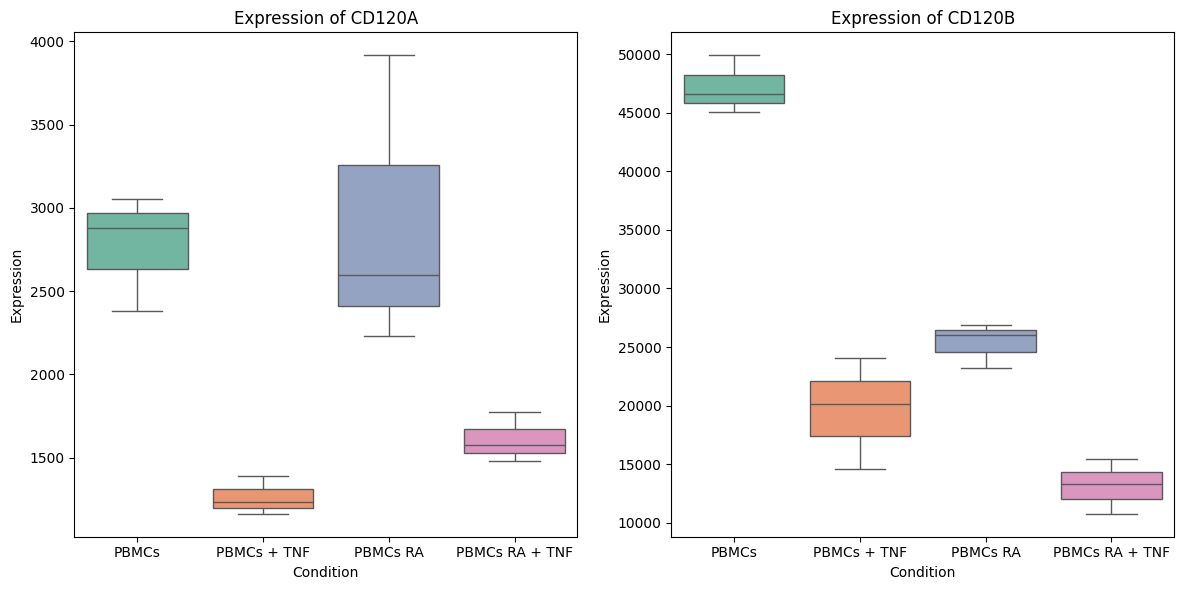

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for differential expression of TNFR1 and TNFR2
genes_to_plot = ['CD120A', 'CD120B']

# Extract the expression data for these genes and include the condition
gene_expression = df.loc[genes_to_plot].T
gene_expression['Condition'] = metadata['Condition']

# Plot the boxplots
plt.figure(figsize=(12, 6))

for i, gene in enumerate(genes_to_plot):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x='Condition', y=gene, data=gene_expression, palette="Set2")
    plt.title(f'Expression of {gene}')
    plt.xlabel('Condition')
    plt.ylabel('Expression')

plt.tight_layout()
plt.savefig('BoxPlots TNFR.png', dpi=600, bbox_inches='tight')
plt.show()